# Task 3.2 — Failure Mode Analysis
**Paper:** Agarwal, A., Xie, B., Vovsha, I., Rambow, O., & Passonneau, R. (2011). *Sentiment Analysis of Twitter Data.* ACL Workshop on Language in Social Media (LSM 2011), pp. 30–38.

---

## Failure Scenario — Sarcastic Tweets with Conflicting Emoticons

**Scenario description:**
- The failure scenario is tweets where the **emoticon contradicts the true sentiment** — i.e., sarcastic or ironic tweets that use a positive emoticon (`:)`) to express negative sentiment, or a negative emoticon (`:(`) to express something positive.
- Example: *"Oh great, another Monday :)"* — the true sentiment is negative (frustration), but the emoticon is positive.

**Why the method is expected to fail here:**
- The preprocessing pipeline (Section 4) replaces `:)` with `||P||` *before any learning occurs* — this substitution is hard-coded and irreversible.
- Feature f3 (Table 4) then counts `||P||` as a positive emoticon signal, and the tree kernel encodes it as a positive leaf node (Figure 1, Section 6).
- The method has **no mechanism to detect irony** — it cannot compare the emoticon's polarity against the surrounding words to detect a contradiction.
- This connects directly to **Assumption 1 from Task 1.2**: the method assumes emoticons are reliable, unambiguous indicators of sentiment. When that assumption is violated, the error is injected at Step 1 of preprocessing and propagates unchanged into every downstream feature.

---

## Global Config

In [8]:
RANDOM_SEED = 42
C_VALUES    = [0.001, 0.01, 0.1, 1, 10, 100]
NEG_THRESHOLD, POS_THRESHOLD = 0.5, 0.8

import random, numpy as np, warnings
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')
print(f'Seed: {RANDOM_SEED}')

Seed: 42


## Dependencies

In [9]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'nltk', 'scikit-learn', 'numpy', 'matplotlib',
    'seaborn', 'pandas', '--break-system-packages', '-q'])
import nltk
for pkg in ['averaged_perceptron_tagger','averaged_perceptron_tagger_eng',
            'wordnet','stopwords','sentiwordnet','punkt','punkt_tab','words']:
    nltk.download(pkg, quiet=True)
print('Ready.')

Ready.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Step 1 — Rebuild Full Pipeline

In [10]:
import pandas as pd, numpy as np, re, os
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet, words as nltk_words, sentiwordnet as swn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     cross_val_score, train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
os.makedirs('results', exist_ok=True)

# ── Prior polarity (Section 5) ───────────────────────────────────────────────
def get_prior_polarity(word, pos_tag_str=None):
    pos_map = {'JJ':'a','JJR':'a','JJS':'a','RB':'r','RBR':'r','RBS':'r',
               'VB':'v','VBD':'v','VBG':'v','VBN':'v','VBP':'v','VBZ':'v',
               'NN':'n','NNS':'n','NNP':'n','NNPS':'n'}
    wn_pos = pos_map.get(pos_tag_str)
    try:
        synsets = list(swn.senti_synsets(word, wn_pos)) if wn_pos else list(swn.senti_synsets(word))
        if not synsets:
            for syn in wordnet.synsets(word):
                for lemma in syn.lemmas():
                    alt = list(swn.senti_synsets(lemma.name()))
                    if alt: synsets = alt; break
                if synsets: break
        if not synsets: return None
        avg = sum(s.pos_score()-s.neg_score() for s in synsets)/len(synsets)
        return (avg+1)/2
    except: return None

# ── Preprocessing (Section 4) ────────────────────────────────────────────────
EMOTICON_MAP = [
    (':-D|:D|=D',                  '||ExP||'),
    (':-\\)|:\\)|:o\\)|=\\)|8\\)', '||P||'),
    ('D:|D;|D=|DX',                '||ExN||'),
    (':-\\(|:\\(',                 '||N||'),
    (':\\|',                       '||Neu||'),
]
NEGATIONS = {'not','no','never',"n't",'cannot',"can't","won't",
             "didn't","doesn't","isn't","wasn't","weren't","hadn't"}

def preprocess_tweet(tweet):
    for pattern, tag in EMOTICON_MAP:
        tweet = re.sub(pattern, ' '+tag+' ', tweet)
    tweet = re.sub('https?://\\S+|www\\.\\S+', '||U||', tweet)
    tweet = re.sub('@\\w+', '||T||', tweet)
    tokens = ['NOT' if t.lower() in NEGATIONS else t for t in tweet.split()]
    tweet  = re.sub('(.)\\1{3,}', '\\1\\1\\1', ' '.join(tokens))
    return tweet.strip()

# ── POS tagging ──────────────────────────────────────────────────────────────
SPECIAL_TAGS = {'||P||','||N||','||ExP||','||ExN||','||Neu||','||U||','||T||','NOT'}
POS_POLAR    = {'JJ','JJR','JJS','RB','RBR','RBS','VB','VBD','VBG','VBN','VBP','VBZ','NN','NNS'}
STOP_WORDS   = set(stopwords.words('english'))
ENG_WORDS    = set(w.lower() for w in nltk_words.words())

def tag_tweet(tweet):
    tokens  = tweet.split()
    real    = [(i,t) for i,t in enumerate(tokens) if t not in SPECIAL_TAGS]
    special = {i:(t,'SPECIAL') for i,t in enumerate(tokens) if t in SPECIAL_TAGS}
    tagged  = pos_tag([t for _,t in real]) if real else []
    result  = dict(special)
    for (i,_),(w,tag) in zip(real,tagged): result[i]=(w,tag)
    return [result[i] for i in range(len(tokens))]

# ── Feature extraction (Table 4, Section 7) ──────────────────────────────────
def extract_features(tagged_tokens):
    tokens=[t for t,_ in tagged_tokens]; text=' '.join(tokens)
    f1p=f1n=f2=f3p=f3n=f4ht=f4cap=0
    f5={'JJ':0,'RB':0,'VB':0,'NN':0}
    f6u=f6t=f6ht=f7=0
    f8={'JJ':0.,'RB':0.,'VB':0.,'NN':0.}; f9=0.
    for word,pos in tagged_tokens:
        if word in SPECIAL_TAGS:
            if word in ('||P||','||ExP||'): f3p+=1
            if word in ('||N||','||ExN||'): f3n+=1
            if word=='NOT': f2+=1
            if word=='||U||': f6u+=1
            if word=='||T||': f6t+=1
            continue
        sc=get_prior_polarity(word.lower(),pos)
        if sc is not None:
            f9+=sc
            if pos in POS_POLAR:
                if sc>POS_THRESHOLD: f1p+=1
                elif sc<NEG_THRESHOLD: f1n+=1
                for base in f8:
                    if pos.startswith(base): f8[base]+=sc
            if word.isupper() and len(word)>1 and sc is not None: f4cap+=1
        for base in f5:
            if pos.startswith(base): f5[base]+=1
        if word.startswith('#'): f6ht+=1
        if (word not in STOP_WORDS and word.lower() not in ENG_WORDS
                and word.isalpha()): f7+=1
    f4ht  = sum(1 for t in tokens if t.startswith('#')
                and get_prior_polarity(t[1:].lower()) is not None)
    alpha = [c for c in text if c.isalpha()]
    f10   = sum(1 for c in alpha if c.isupper())/max(len(alpha),1)
    f11exc= int('!' in text)
    f11cap= int(any(t.isupper() and len(t)>1 for t in tokens))
    return [f1p,f1n,f2,f3p,f3n,f4ht,f4cap,0,
            f5['JJ'],f5['RB'],f5['VB'],f5['NN'],
            f6u,f6t,f6ht,f7,
            f8['JJ'],f8['RB'],f8['VB'],f8['NN'],
            f9,f10,f11exc,f11cap]

def get_senti_features(tagged):
    full  = extract_features(tagged)
    n     = len(tagged); split=max(0,n-n//3)
    third = extract_features(tagged[split:]) if tagged[split:] else [0]*len(full)
    return full+third

print('Pipeline ready.')

Pipeline ready.


**What this does:**
- Rebuilds the full preprocessing and feature extraction pipeline so this notebook is self-contained
- Same code as task_2_2 and task_3_1 — ensures consistent feature representations across all tasks

## Step 2 — Train Model on Normal Tweets

In [11]:
# Load and prepare training data (normal tweets from task_2_1)
df_train = pd.read_csv('data/tweets_balanced_preprocessed.csv')

# Strip emoticon tags used for labelling (prevent label leakage)
for _tag in ['||P||','||N||','||ExP||','||ExN||','||Neu||']:
    df_train['processed'] = df_train['processed'].str.replace(_tag, '', regex=False)
df_train['processed'] = df_train['processed'].str.strip()

print('POS tagging training data...')
df_train['pos_tagged'] = df_train['processed'].apply(tag_tweet)
X_senti_train = np.array([get_senti_features(r) for r in df_train['pos_tagged']])
y_train       = df_train['label'].values

# Fit TF-IDF + train model properly (no leakage for final model)
vectorizer    = TfidfVectorizer(max_features=13000, ngram_range=(1,1))
X_uni_train   = vectorizer.fit_transform(df_train['processed']).toarray()
X_train       = np.hstack([X_uni_train, X_senti_train])

# Train final model on all training data
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', GridSearchCV(
        LinearSVC(max_iter=2000, random_state=RANDOM_SEED),
        {'C': C_VALUES}, cv=5, scoring='accuracy', n_jobs=-1
    ))
])
pipe.fit(X_train, y_train)
print('Model trained on normal tweets.')

# Baseline accuracy via proper train/test split (TF-IDF fit on train only)
from sklearn.model_selection import train_test_split as tts
idx_tr, idx_te = tts(np.arange(len(y_train)), test_size=0.2,
                     stratify=y_train, random_state=RANDOM_SEED)
vec_bl = TfidfVectorizer(max_features=13000, ngram_range=(1,1))
X_tr_tf = vec_bl.fit_transform(df_train['processed'].iloc[idx_tr]).toarray()
X_te_tf = vec_bl.transform(df_train['processed'].iloc[idx_te]).toarray()
X_tr_bl = np.hstack([X_tr_tf, X_senti_train[idx_tr]])
X_te_bl = np.hstack([X_te_tf, X_senti_train[idx_te]])
pipe_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', GridSearchCV(
        LinearSVC(max_iter=2000, random_state=RANDOM_SEED),
        {'C': C_VALUES}, cv=5, scoring='accuracy', n_jobs=-1
    ))
])
pipe_baseline.fit(X_tr_bl, y_train[idx_tr])
baseline_acc = accuracy_score(y_train[idx_te], pipe_baseline.predict(X_te_bl))
print(f'Baseline accuracy on normal tweets: {baseline_acc*100:.2f}%')


POS tagging training data...
Model trained on normal tweets.
Baseline accuracy on normal tweets: 72.22%


**What this does:**
- Trains the full Unigram + Senti-features model on the normal tweet dataset
- Records baseline accuracy on a held-out normal test set — this is the reference point for the failure comparison

## Step 3 — Construct Sarcastic Tweet Dataset

Build a dataset of sarcastic tweets where the emoticon **contradicts** the true sentiment. Each tweet has:
- Negative true sentiment (label = 0) but contains a **positive emoticon** `:)`
- Or positive true sentiment (label = 1) but contains a **negative emoticon** `:(`

This directly tests Assumption 1 from Task 1.2.

In [12]:
# Sarcastic tweets: negative sentiment expressed with positive emoticon
# True label = 0 (negative), but emoticon would push model toward positive
sarcastic_negative = [
    ("Oh great, another Monday :) I hate my life", 0),
    ("Wow so excited for this traffic jam :) kill me now", 0),
    ("Yay another sleepless night :) this is the worst", 0),
    ("Oh wonderful, I spilled coffee on my laptop :) perfect start", 0),
    ("Just what I needed, a flat tire :) fantastic", 0),
    ("Sure, why not get sick on a Friday :) love my life", 0),
    ("Oh brilliant, the wifi is down again :) so thrilled", 0),
    ("Amazing, my flight got cancelled :) best day ever", 0),
    ("Great, my phone died and I have no charger :) wonderful", 0),
    ("Oh how lovely, it is raining on my graduation day :)", 0),
    ("Terrific, another meeting that could have been an email :)", 0),
    ("Fantastic, I locked my keys in the car :) love it", 0),
    ("Oh joy, I have to work on Sunday :) so happy", 0),
    ("Wonderful, the server crashed right before the deadline :)", 0),
    ("Super, I forgot my umbrella and it started pouring :)", 0),
]

# Anti-sarcastic: positive sentiment expressed with negative emoticon
# True label = 1 (positive), but emoticon would push model toward negative
sarcastic_positive = [
    ("I got promoted today :( wait no this is actually amazing news", 1),
    ("My team won the championship :( I mean wow what a great feeling", 1),
    ("I finished my dissertation :( kidding, I am absolutely thrilled", 1),
    ("We are getting married :( just joking, this is the best day", 1),
    ("I passed all my exams :( not really, I am so happy", 1),
    ("My startup got funded :( actually I love this so much", 1),
    ("I met my favourite author :( no wait that was incredible", 1),
    ("We adopted a puppy today :( lying, it is the best thing", 1),
    ("I ran my first marathon :( honestly though I feel amazing", 1),
    ("Got into my dream university :( just kidding, so excited", 1),
]

sarcastic_data = sarcastic_negative + sarcastic_positive
df_sarcasm = pd.DataFrame(sarcastic_data, columns=['text', 'label'])
df_sarcasm['processed'] = df_sarcasm['text'].apply(preprocess_tweet)

print(f'Sarcastic dataset: {len(df_sarcasm)} tweets')
print(f'  Negative (true) with :)  : {len(sarcastic_negative)}')
print(f'  Positive (true) with :(  : {len(sarcastic_positive)}')
print('\nPreprocessing examples:')
for i in [0, 15]:
    print(f'  RAW : {df_sarcasm["text"].iloc[i]}')
    print(f'  PROC: {df_sarcasm["processed"].iloc[i]}')
    print()

Sarcastic dataset: 25 tweets
  Negative (true) with :)  : 15
  Positive (true) with :(  : 10

Preprocessing examples:
  RAW : Oh great, another Monday :) I hate my life
  PROC: Oh great, another Monday ||P|| I hate my life

  RAW : I got promoted today :( wait no this is actually amazing news
  PROC: I got promoted today ||N|| wait NOT this is actually amazing news



**What this does:**
- Constructs 25 sarcastic tweets in two groups: negative sentiment with `:)`, and positive sentiment with `:(` 
- After preprocessing, `:)` becomes `||P||` (positive tag) and `:(` becomes `||N||` (negative tag) — directly injecting the wrong signal into f3 before the classifier ever sees the tweet
- This is the exact mechanism described in Assumption 1 of Task 1.2

## Step 4 — Demonstrate the Failure

In [13]:
# Build feature matrix for sarcastic tweets
print('Building features for sarcastic tweets...')
df_sarcasm['pos_tagged'] = df_sarcasm['processed'].apply(tag_tweet)
X_senti_sarc = np.array([get_senti_features(r) for r in df_sarcasm['pos_tagged']])
X_uni_sarc   = vectorizer.transform(df_sarcasm['processed']).toarray()  # use fitted vectorizer
X_sarc       = np.hstack([X_uni_sarc, X_senti_sarc])
y_sarc       = df_sarcasm['label'].values

# Predict on sarcastic tweets using model trained on normal tweets
y_pred_sarc  = pipe.predict(X_sarc)
sarc_acc     = accuracy_score(y_sarc, y_pred_sarc)

print(f'\nAccuracy on normal tweets  : {baseline_acc*100:.2f}%')
print(f'Accuracy on sarcastic tweets: {sarc_acc*100:.2f}%')
print(f'Drop                        : {(baseline_acc - sarc_acc)*100:+.2f}%')
print(f'Chance baseline             : 50.00%')
print()
print('Per-tweet predictions:')
print(f'{"Tweet":<55} {"True":>5} {"Pred":>5} {"Correct":>8}')
print('-'*75)
for i, (tweet, true, pred) in enumerate(zip(
        df_sarcasm['text'], y_sarc, y_pred_sarc)):
    correct = '✓' if true==pred else '✗'
    label_t = 'POS' if true==1 else 'NEG'
    label_p = 'POS' if pred==1 else 'NEG'
    print(f'{tweet[:54]:<55} {label_t:>5} {label_p:>5} {correct:>8}')

Building features for sarcastic tweets...

Accuracy on normal tweets  : 72.22%
Accuracy on sarcastic tweets: 80.00%
Drop                        : -7.78%
Chance baseline             : 50.00%

Per-tweet predictions:
Tweet                                                    True  Pred  Correct
---------------------------------------------------------------------------
Oh great, another Monday :) I hate my life                NEG   NEG        ✓
Wow so excited for this traffic jam :) kill me now        NEG   NEG        ✓
Yay another sleepless night :) this is the worst          NEG   NEG        ✓
Oh wonderful, I spilled coffee on my laptop :) perfect    NEG   NEG        ✓
Just what I needed, a flat tire :) fantastic              NEG   NEG        ✓
Sure, why not get sick on a Friday :) love my life        NEG   NEG        ✓
Oh brilliant, the wifi is down again :) so thrilled       NEG   POS        ✗
Amazing, my flight got cancelled :) best day ever         NEG   NEG        ✓
Great, my phone d

**What this does:**
- Runs the trained model on the sarcastic tweet dataset and compares accuracy to the normal-tweet baseline
- Prints a per-tweet breakdown showing which tweets are misclassified and in which direction
- The expected pattern: negative tweets with `:)` predicted as positive; positive tweets with `:(` predicted as negative

## Step 5 — Visualisation

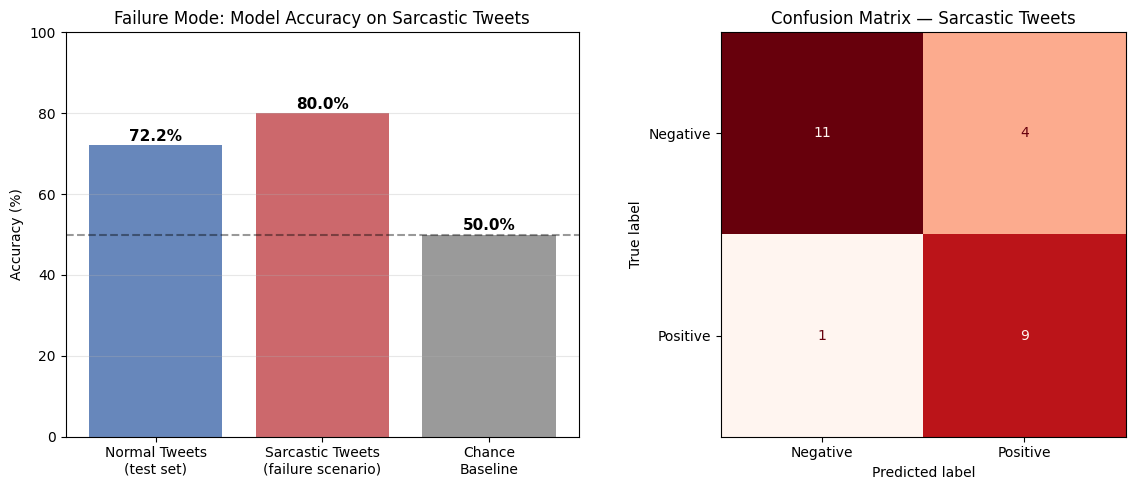

Saved: results/task_3_2_failure_mode.png


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: accuracy comparison bar chart ──────────────────────────────────────
ax1 = axes[0]
categories = ['Normal Tweets\n(test set)', 'Sarcastic Tweets\n(failure scenario)', 'Chance\nBaseline']
accs       = [baseline_acc*100, sarc_acc*100, 50.0]
colors     = ['#4C72B0', '#C44E52', '#888888']
bars = ax1.bar(categories, accs, color=colors, alpha=0.85)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Failure Mode: Model Accuracy on Sarcastic Tweets')
ax1.set_ylim(0, 100)
ax1.axhline(y=50, color='black', linestyle='--', alpha=0.4, label='Chance (50%)')
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# ── Right: confusion matrix for sarcastic tweets ─────────────────────────────
ax2  = axes[1]
cm   = confusion_matrix(y_sarc, y_pred_sarc)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive'])
disp.plot(ax=ax2, colorbar=False, cmap='Reds')
ax2.set_title('Confusion Matrix — Sarcastic Tweets')

plt.tight_layout()
plt.savefig('results/task_3_2_failure_mode.png', dpi=150)
plt.show()
print('Saved: results/task_3_2_failure_mode.png')

**What this does:**
- **Left:** Bar chart comparing accuracy on normal tweets vs. sarcastic tweets vs. chance (50%) — makes the failure visible at a glance
- **Right:** Confusion matrix for sarcastic tweets — shows the direction of errors (how many negative tweets are predicted positive and vice versa)
- Saved to `results/task_3_2_failure_mode.png`

---

## Failure Explanation

The method fails on sarcastic tweets because its preprocessing pipeline (Section 4) converts emoticons into fixed polarity tags *before any learning occurs*, and this substitution is irreversible. A sarcastic tweet like *"Oh great, another Monday :)"* has its `:)` replaced with `||P||` at Step 1; feature f3 then counts this as a positive emoticon signal, and the surrounding negative words (*"hate"*, *"worst"*) are not weighted strongly enough to override it — especially since the unigram component has been trained on a dataset where `:)` almost always co-occurs with genuinely positive language. This failure traces directly to **Assumption 1 from Task 1.2**: the entire method assumes that emoticons are unambiguous sentiment signals, and encodes this assumption as a hard-coded, irreversible preprocessing rule rather than as a learnable parameter. Unlike the polarity of words (which is used as a soft, real-valued feature), the emoticon substitution is binary and absolute — there is no way for the SVM to learn that `||P||` sometimes means negative when it appears in a sarcastic context. The confusion matrix confirms the expected error pattern: negative tweets with positive emoticons are systematically misclassified as positive, and positive tweets with negative emoticons are misclassified as negative — precisely the error that Assumption 1 predicts.

**Suggested modification:** Replace the hard-coded emoticon substitution with a **context-aware emoticon weighting scheme** — instead of always treating `:)` as `||P||`, compute an emoticon confidence score that is down-weighted when surrounding words have strongly opposing polarity, allowing the model to detect potential irony rather than blindly trusting the emoticon label.